## Data Augmentation
What, Why and How of Data Augmentation! [Read More](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html)

In [1]:
import numpy as np
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
import tensorflow
# from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Dropout, Conv2D, Flatten, MaxPooling2D
from keras.optimizers import Adam

#### Data Augumentation using a single image

In [2]:
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator

(numpy.ndarray, (200, 200, 3))

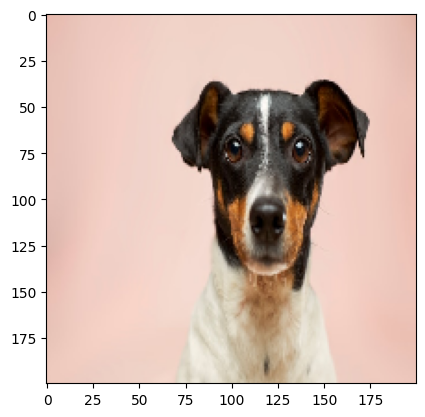

In [3]:
img = image.load_img('x1.jpg', target_size=(200, 200))
plt.imshow(img)
img = image.img_to_array(img)
type(img), img.shape

In [4]:
datagen = ImageDataGenerator(
    rotation_range=40,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
)

In [5]:
# Reshape to (1, height, width, channels)
input_batch = img.reshape((1, 200, 200, 3))

In [6]:
!cd

c:\Users\piyus\Downloads\deep-learning\DL04_CNN


In [7]:

i = 0
for output in datagen.flow(input_batch, batch_size=1, save_to_dir=r'data/aug'):
    i += 1
    if i == 10:
        break

#### Data Augumentation from a directory of images

In [8]:
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator

#### Augmentation Configuration

In [9]:
# this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
)
# this is the augmentation configuration we will use for testing:
test_datagen = ImageDataGenerator(rescale=1.0 / 255)  # only rescaling

In [10]:
# this is a generator that will read pictures found in
# subfolders of 'data/train', and indefinitely generate
# batches of augmented image data
batch_size = 20
train_generator = train_datagen.flow_from_directory(
    directory="data/train",  # Directory containing training images
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='binary')

val_generator = test_datagen.flow_from_directory(
    directory="data/test",  # Directory containing validation images
    target_size=(150, 150),
    batch_size=batch_size,
    class_mode='binary',)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [11]:
print(train_generator.class_indices)
print(val_generator.class_indices)

{'cats': 0, 'dogs': 1}
{'cats': 0, 'dogs': 1}


### Define a Model

#### Conv Layer

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=(150, 150, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

#### Fully Connected Layer

In [13]:
model.add(Flatten())  # this converts our 3D feature maps to 1D feature vectors
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 activation (Activation)     (None, 148, 148, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 32)        9248      
                                                                 
 activation_1 (Activation)   (None, 72, 72, 32)        0         
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 32)       0         
 2D)                                                    

### Train the model with Augmented Data

In [15]:
model.fit(
    train_generator,                  # Training data generator
    steps_per_epoch= 100 // batch_size, # Number of batches per epoch
    epochs=10,                        # Number of epochs to train
    validation_data=val_generator,    # Validation data generator
    validation_steps= 80 // batch_size # Number of validation batches per epoch
)

Epoch 1/10
5/5 [==============================] - 10s 483ms/step - loss: 1.0056 - accuracy: 0.4600 - val_loss: 0.6784 - val_accuracy: 0.6125
Epoch 2/10
5/5 [==============================] - 2s 507ms/step - loss: 0.6888 - accuracy: 0.5500 - val_loss: 0.8396 - val_accuracy: 0.5500
Epoch 3/10
5/5 [==============================] - 2s 471ms/step - loss: 0.7675 - accuracy: 0.5200 - val_loss: 0.6942 - val_accuracy: 0.4750
Epoch 4/10
5/5 [==============================] - 2s 489ms/step - loss: 0.7168 - accuracy: 0.5900 - val_loss: 0.6943 - val_accuracy: 0.4500
Epoch 5/10
5/5 [==============================] - 2s 415ms/step - loss: 0.6895 - accuracy: 0.5400 - val_loss: 0.6962 - val_accuracy: 0.4250
Epoch 6/10
5/5 [==============================] - 2s 418ms/step - loss: 0.6851 - accuracy: 0.5600 - val_loss: 0.6990 - val_accuracy: 0.4500
Epoch 7/10
5/5 [==============================] - 2s 447ms/step - loss: 0.6845 - accuracy: 0.5200 - val_loss: 0.7327 - val_accuracy: 0.4375
Epoch 8/10
5/5 [===

In [18]:
test_img = image.load_img(r'data/d1.jpg', target_size=(150, 150))
test_img = image.img_to_array(test_img)
# predict the class of the image
model.predict(np.expand_dims(test_img, axis=0))

1/1 [==============================] - 0s 20ms/step


array([[1.]], dtype=float32)